In [1]:
import numpy as np
import matplotlib.pyplot as plt
import flpoAgent
import importlib
import random
from scipy.spatial.distance import cdist 
import createEnv
from scipy.optimize import Bounds, LinearConstraint, minimize
import supporting_functions
from matplotlib.cm import get_cmap

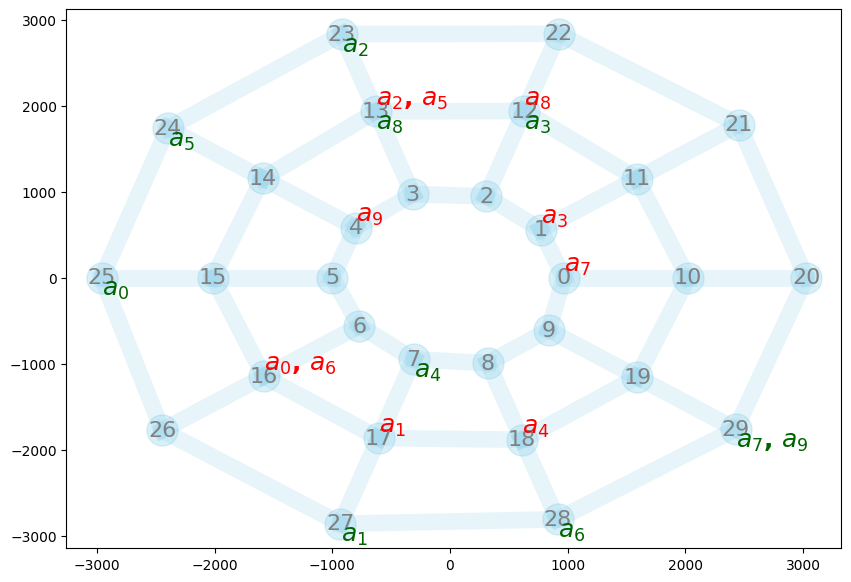

In [2]:
importlib.reload(flpoAgent)
importlib.reload(createEnv)
importlib.reload(supporting_functions)

# generate waypoints and the adjacency matrix
n_waypoints = 30
n_agents = 10
tolArray = np.random.uniform(3.0, 3.0, n_waypoints)

# Grid network parameters
grid_params = {
    'type':'grid',
    'n_points':n_waypoints,
    'grid_size':1000,
    'noise_factor':5
}

# Ring network parameters
ring_params = {
    'type':'ring',
    'num_rings':3,
    'points_per_ring':int(n_waypoints/3),
    'center_distance':1000,
    'deformation_level':50.0,
    'extra_connections':0.00,
    'missing_connections':0.05
}

# create a mars environment
mars = createEnv.MARS(
    n_waypoints, 
    n_agents, 
    tolArray, 
    ring_params, 
    seed=11, 
    offset_energy=1,
    stagewiseCostCoeffs=np.array([10.0, 100.0, 1.0]),
    selfHop=0,
    printFlag=False)

# compute conflict cost
beta0=1e-8
gamma_t = 5
gamma_c = 7.5
coeff_t = 50
coeff_c = 5.0

# mars visualization
cmap = get_cmap('tab20')
agent_colors = {a: cmap(i / mars.n_agents) for i, a in enumerate(range(mars.n_agents))}
createEnv.plotNetwork(mars=mars, figuresize=(10,7), routes=[], agent_colors=agent_colors, showEdgeLength=False)

# agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



### Write a code to solve MARS using CBF-CLF based appraoch

In [3]:
beta_min = 1e-3
beta_max = 1e4
beta_grow = 2
beta = beta_min
beta_arr = []
while beta <= beta_max:
    beta_arr.append(beta)
    beta = beta * beta_grow

T0 = np.ones((mars.n_agents, mars.n_waypoints))
for i in range(mars.n_agents):
    if i > 0:
        T0[i] = T0[i-1] + mars.tolArray + np.random.uniform(0,5, mars.tolArray.shape)
# T0 = np.random.uniform(0, 1, (mars.n_agents, mars.n_waypoints))
# T0 = np.array([
#     [12.77, 25.54, 0.0],
#     [12.67, 0.0, 25.4]
# ])
V0 = mars.speed_vec
# V0 = mars.speed_lim_mat[:,-1]

optimizer = {
    'name':'cbf_clf',
    'dt_init':0.01,
    'dt_min':1e-5,
    'dt_max':0.5,
    'Tf':6,
    'gamma':1,
    'alpha':1,
    'p':1,
    'stop_tol':0.07,
    'stop_tol_weight':np.array([1, 1, 5, 5]),
    'verbose':0
}



In [4]:

active_waypoints = range(mars.n_waypoints)
# mars.stagewiseCostCoeffs = np.array([1.0, 1000.0, 1.0])
T, V, F, Pb_a = mars.anneal(
    beta_arr, 
    T0, 
    V0, 
    active_waypoints=active_waypoints, 
    optimizer=optimizer, 
    annealPrint=True)




beta: 1.0000e-03	cost: 5267.874	dot_cost: -3010.031	tolb: 6.375e-02	delta_b: 2258.497	n_active_waypoints:30	tol_mag:0.01	agent_weights:[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]

beta: 2.0000e-03	cost: 3761.349	dot_cost: -2336.402	tolb: 4.754e-02	delta_b: 1424.947	n_active_waypoints:30	tol_mag:0.02	agent_weights:[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]

beta: 4.0000e-03	cost: 2994.238	dot_cost: -2001.118	tolb: 6.928e-02	delta_b: 993.120	n_active_waypoints:30	tol_mag:0.04	agent_weights:[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]

beta: 8.0000e-03	cost: 2580.926	dot_cost: -1729.203	tolb: 6.229e-02	delta_b: 851.724	n_active_waypoints:30	tol_mag:0.08	agent_weights:[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]

beta: 1.6000e-02	cost: 2349.672	dot_cost: -1577.791	tolb: 5.411e-02	delta_b: 771.881	n_active_waypoints:30	tol_mag:0.16	agent_weights:[0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1 0.1]

beta: 3.2000e-02	cost: 2217.219	dot_cost: -1467.269	tolb: 6.031e-02	delta_b: 749.951	n_active_waypoints:30	tol_m

In [5]:
mars.transportCost_v1(T, V, beta=beta_arr[-1], allowPrint=True)
np.sum(mars.agent_weights * mars.C_agents)


individual agent costs:
v1:	412.57
v2:	221.72
v3:	3509.84
v4:	583.65
v5:	439.82
v6:	844.09
v7:	5469.88
v8:	937.19
v9:	45502.42
v10:	9600.62
sum: [  412.57448321   221.71786412  3509.83647365   583.65029457
   439.81806317   844.0927208   5469.87509324   937.185464
 45502.41995323  9600.61629173]


6752.1786701722085

route v0: [25, 15, 16], schedule: [ 0.39 12.73 28.76],	mean_spd: 76.56,	max_spd: 76.58,	min_spd: 76.53,	speed_lim: [ 0.72 79.21]
route v1: [27, 17], schedule: [ 0.12 14.84],	mean_spd: 71.21,	max_spd: 71.21,	min_spd: 71.21,	speed_lim: [ 0.52 74.11]
route v2: [23, 13], schedule: [0.01 7.4 ],	mean_spd: 128.02,	max_spd: 128.02,	min_spd: 128.02,	speed_lim: [ 0.79 71.9 ]
route v3: [12, 2, 1], schedule: [ 5.02 20.72 29.8 ],	mean_spd: 66.45,	max_spd: 66.48,	min_spd: 66.42,	speed_lim: [ 0.59 72.04]
route v4: [7, 8, 18], schedule: [ 3.81 11.2  22.46],	mean_spd: 84.43,	max_spd: 85.65,	min_spd: 83.21,	speed_lim: [ 0.74 78.64]
route v5: [24, 14, 13], schedule: [ 5.84 19.85 37.31],	mean_spd: 70.96,	max_spd: 70.96,	min_spd: 70.95,	speed_lim: [ 0.68 71.55]
route v6: [28, 18, 17, 16], schedule: [ 16.79  42.68  74.2  105.37],	mean_spd: 38.36,	max_spd: 38.80,	min_spd: 37.62,	speed_lim: [ 0.97 77.75]
route v7: [29, 19, 9, 0], schedule: [ 6.12 22.17 36.62 46.26],	mean_spd: 64.43,	max_spd: 64.58,	min_spd: 6

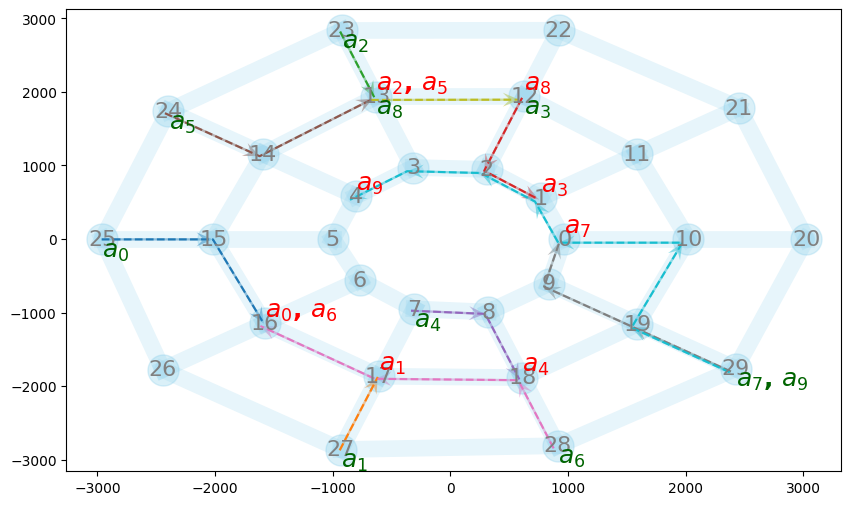

In [6]:
mars.sched_mat = T
agent_routes, agent_schedules = createEnv.calc_agent_routes_and_schedules(mars, Pb_a, printRoutes=True)
createEnv.plotNetwork(mars=mars, figuresize=(10,6), routes=agent_routes, agent_colors=agent_colors, showEdgeLength=False)


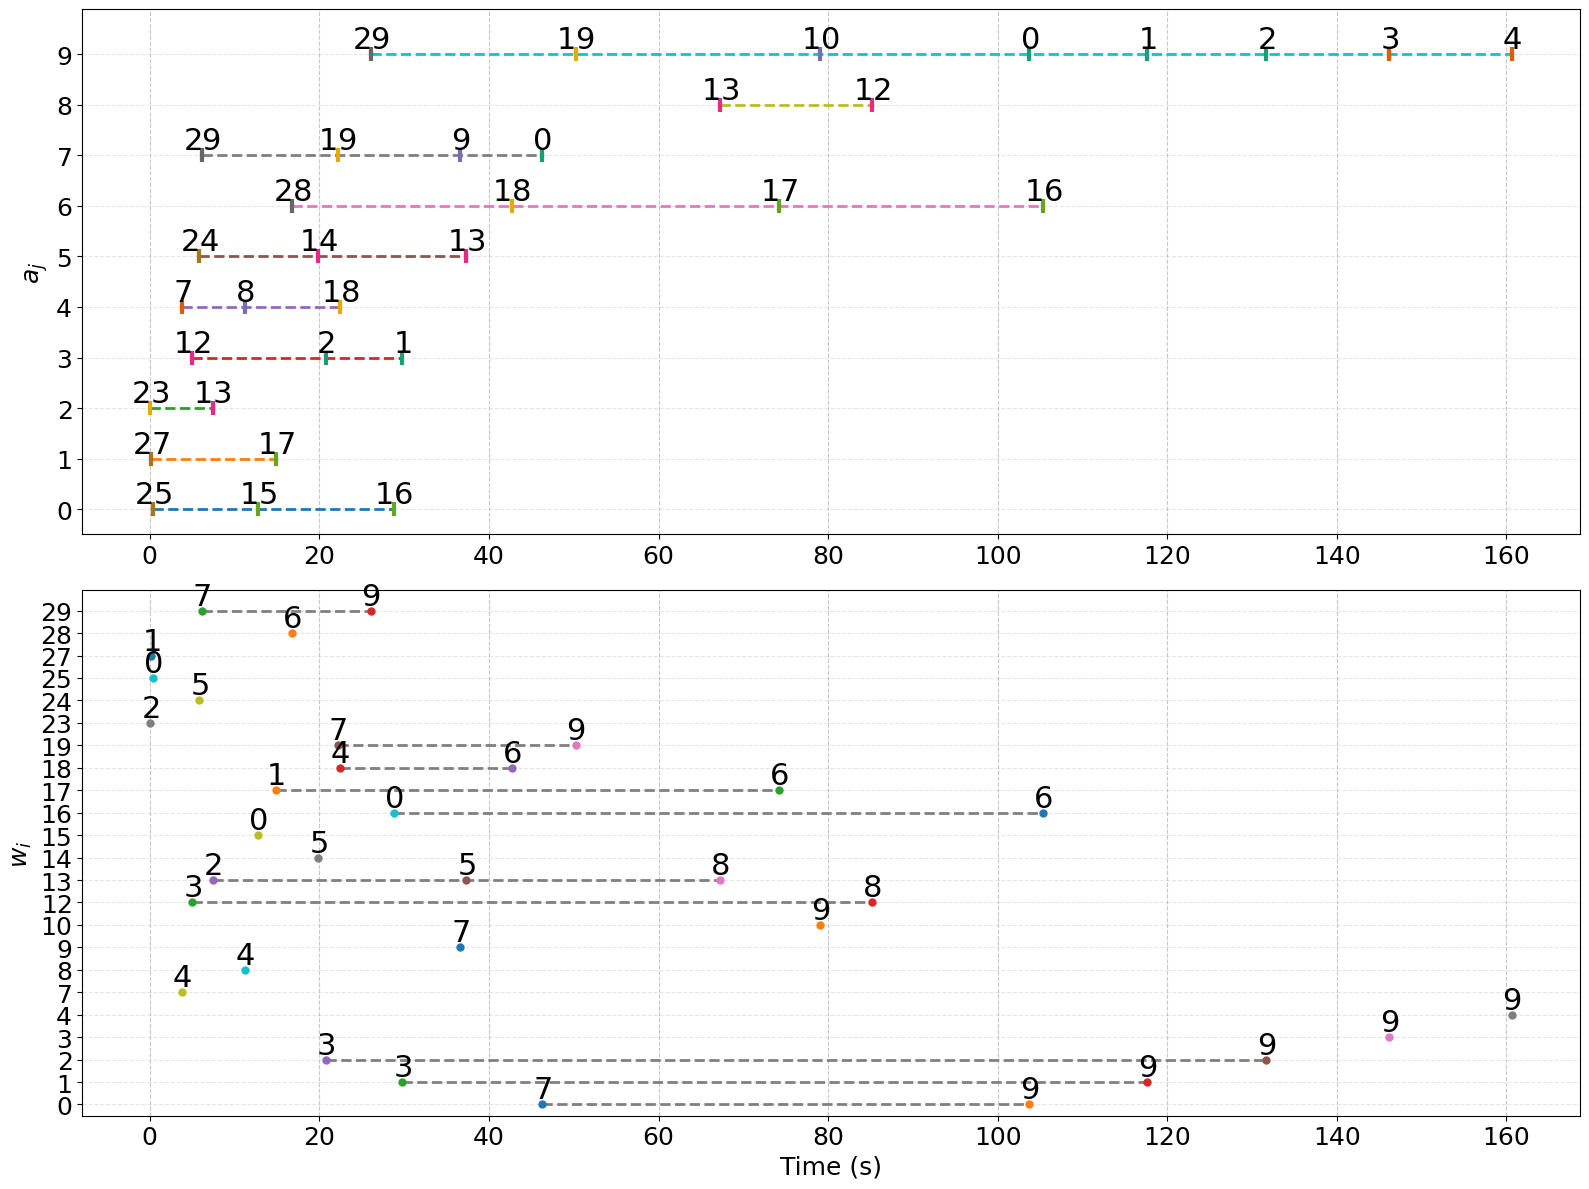

In [7]:
reach_mat = mars.calc_agent_reach_mat_v1(
    mars.sched_mat,
    mars.speed_vec,
    beta=beta_arr[-1]
)
association_mat = np.ones(shape=reach_mat.shape)
association_mat[reach_mat <= 1e-10] = 0.0

createEnv.plot_waypoint_agent_schedules(
    agent_routes,
    agent_schedules,
    mars.sched_mat,
    association_mat,
    mars.process_T,
    agent_colors,
    figuresize=(16,12)
)

In [3]:
# agent_0 = mars.agents[0]
# sched0_init = mars.sched_mat[0,:]
# lb0 = np.zeros(sched0_init.shape)
# ub0 = 100 * np.ones(lb0.shape)
# bounds = Bounds(lb0, ub0)
# speed = 50

In [4]:
# beta_min = 1e-5
# beta_max = 1e3
# beta_grow = 3
# beta = beta_min
# beta_arr = []
# while beta <= beta_max:
#     beta_arr.append(beta)
#     beta = beta * beta_grow

In [5]:
# for i, b in enumerate(beta_arr):
#     res = minimize(
#         agent_0.getFreeEnergy_s_v1,
#         sched0_init,
#         args = (mars.dist_mat, b),
#         method='slsqp',
#         options={'disp':0},
#         bounds=bounds
#     )
#     sched0_init = res.x

#     print(f'beta:{b:.4e}\tfreeEnergy:{res.fun:.4f}')



### Test the optimization for all the agents together

In [7]:
# # annealing
# sched_vec0 = mars.sched_mat.flatten()

# lb = np.ones(shape=sched_vec0.shape)*mars.t_start_min
# ub = np.ones(shape=sched_vec0.shape)*100.0
# print(f'agent start nodes {mars.agents[0].s}')
# print(f'init schedule vec {sched_vec0}')
# print(f'ub {ub}')
# print(f'lb {lb}')

# sched_bounds = [lb,ub]
# beta_lims = [1e-6,1]
# beta_grow = 1.5
# # opts = {'gtol':1e-4, 'verbose':0, 'maxiter':200}
# opts = {'disp':0}
# C_arr, sched_vec, rt_arr, reach_mat_beta_data, filter_wp_beta_data, beta_arr, gamma_arr, conflict_C_arr, Pb_a = mars.annealing_v1(beta_lims=beta_lims,
#                                             beta_grow=beta_grow,
#                                             sched_vec0=sched_vec0,
#                                             init_sched_bounds=sched_bounds,
#                                             optimize_opt=opts,
#                                             allowPrintAnneal=True,
#                                             allowPrintOptimize=False)

# # C_arr, sched_vec, rt_arr, reach_mat_beta_data, filter_wp_beta_data, beta_arr, gamma_arr, conflict_C_arr, Pb_a = mars.annealing(beta_lims=beta_lims,
# #                                             beta_grow=beta_grow,
# #                                             sched_vec0=sched_vec0,
# #                                             init_sched_bounds=sched_bounds,
# #                                             optimize_opt=opts,
# #                                             allowPrintAnneal=True,
# #                                             allowPrintOptimize=False)



In [8]:
# importlib.reload(createEnv)
# importlib.reload(flpoAgent)
# print('\nOptimization Results')
# print(f'initial schedule:{sched_vec0}')
# print(f'final schedule:\n{mars.sched_mat}')
# print(f'processing time:\n{mars.process_T}')
# print(f'cost:{C_arr[-1]}')

# agent_routes, agent_schedules = createEnv.calc_agent_routes_and_schedules(mars, Pb_a, printRoutes=True)
# createEnv.plotNetwork(mars=mars, figuresize=(12,8), routes=agent_routes, agent_colors=agent_colors, showEdgeLength=False, plotPaths=True)
# # createEnv.plot_vehicle_routes(agent_routes, agent_schedules, mars.process_T, agent_colors)
# # createEnv.plot_waypoint_schedules(filter_wp_beta_data[-1], mars.sched_mat)
# createEnv.plot_waypoint_agent_schedules(
#     agent_routes, agent_schedules, mars.sched_mat, 
#     filter_wp_beta_data[-1], mars.process_T, agent_colors,
#     figuresize=(12,12))
# plt.figure(figsize=(8,4))
# plt.plot(np.log(beta_arr)/np.log(10), conflict_C_arr.sum(axis=1), marker='o', linewidth=2, color='red')
# plt.xlabel(rf'$\log\beta$', fontsize=14)
# plt.ylabel(rf'Cost', fontsize=14)
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.grid()
# plt.show()
# # agent visualization
# show_graph=0
# if show_graph:
#     for i,v in enumerate(mars.agents):
#         v.showGraph(mars.wp_locations, mars.dist_mat, mars.mask, mars.sched_mat[i,:], figuresize=(10,5), showEdgeTimeLim=True)



In [15]:


# reach_mat = mars.calc_agent_reach_mat_v1(mars.sched_mat, beta_arr[-1])
# filter_wp = np.ones(shape=reach_mat.shape)
# filter_wp[reach_mat <= 1.0e-10] = 0.0
# createEnv.plot_waypoint_agent_schedules(agent_routes, agent_schedules, mars.sched_mat, filter_wp, mars.process_T, agent_colors, figuresize=(16,18))



In [1]:
import cvxpy as cp
import numpy as np

def F_Fgrad1(V, t1, t2, t3, l1, l2):
    cost = (l2/V)**2 + (t3 - t2 - l2/V)**2 + (l1/V)**2 + (t2 - t1 - l1/V)**2 + t1**2
    grad = np.array([
        2*(t1 - t2 + l1/V) + 2*t1,
        2*(t2 - t1 - l1/V) + 2*(t2 - t3 + l2/V),
        2*(t3 - t2 - l2/V),
        2*l2/V**2 * (t2 - t1 - 2*l2/V) + 2*l1/V**2 * (t3 - t2 - 2*l1/V)
    ])
    return cost, grad

def H_Hgrad(V, Vmin, Vmax):
    H = (Vmax - V)*(V - Vmin)
    grad_H = Vmax + Vmin - 2*V
    return H, grad_H


In [5]:
U1 = cp.Variable(1)
U2 = cp.Variable(1)
U3 = cp.Variable(1)
U4 = cp.Variable(1)
U5 = cp.Variable(1)
U6 = cp.Variable(1)
U7 = cp.Variable(1)
U8 = cp.Variable(1)
delta = cp.Variable(1)

t1, t2, t3 = np.random.uniform(0,1000, 3)
t4, t5, t6 = np.random.uniform(0,1000, 3)
V1, V2 = np.random.uniform(10,20,2)
gamma = 1
alpha = 0.01
iters = 3000
step_size = 0.01

l1 = 1000
l2 = 1000
Vmin1, Vmax1 = 0.1, 73
Vmin2, Vmax2 = 0.1, 100

for i in range(iters):
    objective = cp.Minimize(U1**2 + U2**2 + U3**2 + U4**2 + U5**2 + U6**2 + U7**2 + U8**2 + delta**2)

    F1, Fgrad1 = F_Fgrad1(V1, t1, t2, t3, l1, l2)
    Fdot1 = cp.multiply(Fgrad1[0], U1) + cp.multiply(Fgrad1[1], U2) + cp.multiply(Fgrad1[2], U3) + cp.multiply(Fgrad1[3], U4)

    F2, Fgrad2 = F_Fgrad1(V2, t4, t5, t6, l2, l1)
    Fdot2 = cp.multiply(Fgrad2[0], U5) + cp.multiply(Fgrad2[1], U6) + cp.multiply(Fgrad2[2], U7) + cp.multiply(Fgrad2[3], U8)

    F = F1 + F2
    Fdot = Fdot1 + Fdot2

    H1, Hgrad1 = H_Hgrad(V1, Vmax1, Vmin1)
    Hdot1 = cp.multiply(Hgrad1, U4)

    H2, Hgrad2 = H_Hgrad(V2, Vmax2, Vmin2)
    Hdot2 = cp.multiply(Hgrad2, U8)

    constraints = [
        Fdot <= -gamma * F + delta,
        Hdot1 >= -alpha * H1,
        Hdot2 >= -alpha * H2,
        U1 >= -alpha * t1,
        U5 >= -alpha * t4
    ]

    problem = cp.Problem(objective, constraints)
    solver_options = {
        'max_iter': 50000,         # Increase max iterations to 20000
        'eps_abs': 1e-4,           # Adjust absolute tolerance
        'eps_rel': 1e-4,           # Adjust relative tolerance
        'eps_prim_inf': 1e-3,      # Adjust primal infeasibility tolerance
        'eps_dual_inf': 1e-3,      # Adjust dual infeasibility tolerance
        'verbose': False           # Enable verbose output to track solver progress
    }
    result = problem.solve(solver = 'OSQP', **solver_options)

    t1 = t1 + step_size * U1.value
    t2 = t2 + step_size * U2.value
    t3 = t3 + step_size * U3.value
    V1 = V1 + step_size * U4.value
    t4 = t4 + step_size * U5.value
    t5 = t5 + step_size * U6.value
    t6 = t6 + step_size * U7.value
    V2 = V2 + step_size * U8.value

    print((Hdot1.value + alpha * H1)[0], (Hdot2.value + alpha * H2)[0], H1, H2)
    # if i > 0:
    #     print(f'F:{F[0]:.1f}\tFdot:{Fdot.value[0]:.1f}\tt1:{t1[0]:.1f}\tt2:{t2[0]:.1f}\tt3:{t3[0]:.1f}\tV:{V1[0]:.1f}\tt4:{t4[0]:.1f}\tt5:{t5[0]:.1f}\tt6:{t6[0]:.1f}\tV2:{V2[0]:.1f}')
    # print(f'iter:{i}\tt1:{t1[0]:.3f}\tt2:{t2[0]:.3f}\tt3:{t3[0]:.3f}\tV:{V[0]:.3f}\tU1:{U1.value[0]:.3f}\tU2:{U2.value[0]:.3f}\tU3:{U3.value:.3f}')


2024.1478992154791 16437.443818146643 769.165648373217 1311.1166719225225
2816.6136026300055 18310.76120885011 [789.14850594] [1469.66353057]
3451.6418463226787 18689.949722664416 [816.87012968] [1644.46233937]
3591.9398401682583 17079.408767226414 [850.72557848] [1820.94802741]
3251.0433263533023 14189.494617482143 [885.8881315] [1980.76398921]
2728.594286265998 11172.001936793375 [917.71637878] [2112.69982277]
2237.708542017742 8618.961952313633 [944.46059385] [2216.07744862]
1839.3918445983404 6609.229352997092 [966.42010001] [2295.42136997]
1529.069001697505 5046.460219910424 [984.4862841] [2355.85036365]
1287.9278980988818 3818.4110999475915 [999.51084653] [2401.54665456]
1098.5241158928065 2836.031321957606 [1012.16611231] [2435.63920969]
947.5506057574712 2034.9428384578123 [1022.95654618] [2460.42666412]
825.36891542276 1369.543515372607 [1032.25789478] [2477.60787813]
725.0591800549481 807.3818383703768 [1040.35231692] [2488.45647407]
641.6185688307253 325.0429139460003 [1047.